# Predicting Spotify Track Popularity through Bayesian Reasoning

**Course:** Fundamentals of AI and Knowledge Representation — Module 3 (Bayesian Networks)
**Dataset:** [Spotify Tracks Dataset (Kaggle, maharshipandya)](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

## Aim

This project investigates which musical characteristics of a track (genre, danceability,
energy, mood/valence, explicit content) are most associated with its popularity on Spotify.
We build a custom Bayesian Network and use exact inference to answer a few concrete questions,
such as whether energetic tracks are more popular than "happy"-sounding ones, and how much
genre alone shifts the odds of a track becoming popular.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pickle

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

pd.set_option('display.max_columns', None)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## 2. Load and inspect the dataset

The raw dataset contains 114,000 tracks across 114 genres, with audio features computed via
Spotify's Web API (danceability, energy, valence, etc.), plus a `popularity` score (0-100).

In [2]:
df = pd.read_csv('dataset.csv')
print(f"Full dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Full dataset: 114000 rows, 21 columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Preprocessing

To keep the network small and the CPTs well-estimated (per the course guidelines, we want a
manageable model, not something huge), we:

1. **Restrict to 6 varied genres**: `pop`, `classical`, `jazz`, `metal`, `edm`, `hip-hop` —
   chosen to span very different average popularity levels and musical styles, rather than
   using all 114 genres.
2. **Select 6 relevant columns**: genre, explicit flag, danceability, energy, valence
   (musical "mood"), and popularity (our target).
3. **Discretize continuous features into 3 categories** using *fixed* range cuts
   (0-0.33 / 0.33-0.66 / 0.66-1 for the 0-1 audio features; 0-33 / 33-66 / 66-100 for
   popularity). We use fixed cuts rather than quantile-based ones because popularity is
   heavily skewed (many tracks score 0), which breaks quantile binning and would also be
   harder to justify/interpret in the report.

In [3]:
chosen_genres = ['pop', 'classical', 'jazz', 'metal', 'edm', 'hip-hop']
data = df[df['track_genre'].isin(chosen_genres)].copy()
print(f"Filtered dataset: {data.shape[0]} rows across {len(chosen_genres)} genres")
data['track_genre'].value_counts()

Filtered dataset: 6000 rows across 6 genres


track_genre
classical    1000
edm          1000
hip-hop      1000
jazz         1000
metal        1000
pop          1000
Name: count, dtype: int64

In [4]:
def bin_fixed(series, edges, labels):
    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)

data['Danceability'] = bin_fixed(data['danceability'], [0, 0.33, 0.66, 1.0], ['low', 'med', 'high'])
data['Energy'] = bin_fixed(data['energy'], [0, 0.33, 0.66, 1.0], ['low', 'med', 'high'])
data['Valence'] = bin_fixed(data['valence'], [0, 0.33, 0.66, 1.0], ['sad', 'neutral', 'happy'])
data['Popularity'] = bin_fixed(data['popularity'], [-1, 33, 66, 100], ['low', 'med', 'high'])
data['Genre'] = data['track_genre']
data['Explicit'] = data['explicit']

final = data[['Genre', 'Explicit', 'Danceability', 'Energy', 'Valence', 'Popularity']].dropna()
print(final.shape)
final.head(10)

(6000, 6)


,Genre,Explicit,Danceability,Energy,Valence,Popularity
16000,classical,False,med,low,neutral,med
16001,classical,False,med,high,happy,med
16002,classical,False,med,med,neutral,med
16003,classical,False,high,low,neutral,high
16004,classical,False,med,low,sad,med
16005,classical,False,med,low,neutral,med
16006,classical,False,med,med,happy,med
16007,classical,False,low,low,sad,low
16008,classical,False,med,low,neutral,low
16009,classical,False,med,low,neutral,low


In [5]:
# Sanity check: no tiny/empty bins that would make CPT estimation unreliable
for c in final.columns:
    print(f"\n{c}:")
    print(final[c].value_counts())


Genre:
Genre
classical    1000
edm          1000
hip-hop      1000
jazz         1000
metal        1000
pop          1000
Name: count, dtype: int64

Explicit:
Explicit
False    5356
True      644
Name: count, dtype: int64

Danceability:
Danceability
med     3420
high    1931
low      649
Name: count, dtype: int64

Energy:
Energy
high    2729
med     1865
low     1406
Name: count, dtype: int64

Valence:
Valence
neutral    2707
sad        1862
happy      1431
Name: count, dtype: int64

Popularity:
Popularity
low     3132
med     1612
high    1256
Name: count, dtype: int64


## 4. Network definition (custom model)

We define the structure manually rather than learning it from data, based on a simple,
justifiable causal intuition:

- **Genre → Danceability, Energy, Valence, Explicit**: the genre of a track strongly shapes
  its musical style (e.g. metal tends to be high-energy, classical tends to be low-energy
  and non-explicit).
- **Danceability, Energy, Valence, Explicit → Popularity**: the resulting style/content
  characteristics are what plausibly drive how popular a track becomes, independent of genre
  itself.

This keeps the network small (6 nodes) and free of the "reverse causality" issues that show
up when structure is learned automatically from data (e.g. Popularity influencing Genre,
which makes no causal sense).

In [6]:
edges = [
    ('Genre', 'Danceability'),
    ('Genre', 'Energy'),
    ('Genre', 'Valence'),
    ('Genre', 'Explicit'),
    ('Danceability', 'Popularity'),
    ('Energy', 'Popularity'),
    ('Valence', 'Popularity'),
    ('Explicit', 'Popularity'),
]

model = DiscreteBayesianNetwork(edges)
print("Valid DAG:", model.check_model() if model.get_cpds() else "no CPDs yet")
print("Nodes:", list(model.nodes()))

Valid DAG: no CPDs yet
Nodes: ['Genre', 'Danceability', 'Energy', 'Valence', 'Explicit', 'Popularity']


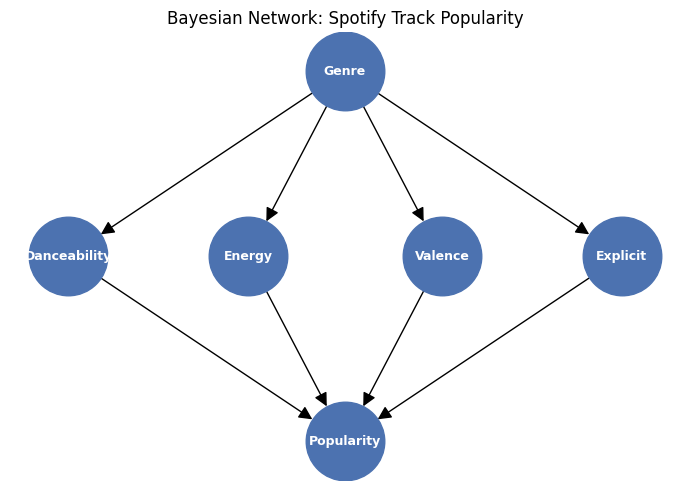

In [7]:
# Visualize the network structure
G = nx.DiGraph()
G.add_edges_from(model.edges())

pos = {
    'Genre': (0, 2), 'Danceability': (-2, 1), 'Energy': (-0.7, 1),
    'Valence': (0.7, 1), 'Explicit': (2, 1), 'Popularity': (0, 0),
}

fig, ax = plt.subplots(figsize=(7, 5))
nx.draw_networkx_nodes(G, pos, node_size=3200, node_color='#4C72B0', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, arrowsize=20, arrowstyle='-|>', node_size=3200, ax=ax)
ax.set_title('Bayesian Network: Spotify Track Popularity')
ax.axis('off')
plt.tight_layout()
plt.savefig('network_diagram.png', dpi=150)
plt.show()

## 5. Parameter learning (CPTs via Maximum Likelihood Estimation)

In [8]:
estimator = DiscreteMLE()
estimator.fit(model, final)
model.add_cpds(*estimator.parameters_)

print("Model is valid:", model.check_model())
model.get_cpds('Popularity')

Model is valid: True


<TabularCPD representing P(Popularity:3 | Danceability:3, Energy:3, Explicit:2, Valence:3) at 0x7fd053007710>

## 6. Inference — Probabilistic queries

### Question 1: Does genre alone shift the odds of popularity?

We query `P(Popularity | Genre = g)` for each of our 6 genres, with no other evidence.

             low    med   high
pop        0.426  0.314  0.260
classical  0.766  0.172  0.062
jazz       0.604  0.254  0.142
metal      0.371  0.345  0.283
edm        0.394  0.322  0.285
hip-hop    0.447  0.273  0.280


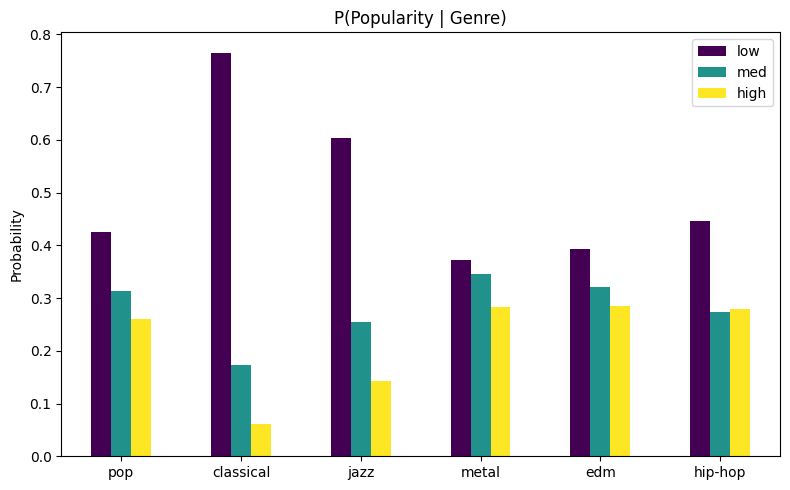

In [9]:
infer = VariableElimination(model)

genre_results = {}
for genre in chosen_genres:
    r = infer.query(variables=['Popularity'], evidence={'Genre': genre}, show_progress=False)
    genre_results[genre] = dict(zip(r.state_names['Popularity'], r.values))

genre_df = pd.DataFrame(genre_results).T[['low', 'med', 'high']]
print(genre_df.round(3))

genre_df.plot(kind='bar', figsize=(8, 5), colormap='viridis')
plt.title('P(Popularity | Genre)')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('query1_genre.png', dpi=150)
plt.show()

**Observation:** Classical (76.6% low) and jazz (60.4% low) are far less likely to be popular
than pop, hip-hop, metal, and edm. Interestingly, metal and edm slightly *edge out* pop for
P(high popularity) in this dataset/sample — a mildly counter-intuitive result worth noting in
the report.

### Question 2: Does mood (valence) matter more than energy for popularity?

We compare `P(Popularity=high | Valence=v)` against `P(Popularity=high | Energy=e)`.

P(high popularity | Valence): {'sad': np.float64(0.226), 'neutral': np.float64(0.244), 'happy': np.float64(0.162)}
P(high popularity | Energy):  {'low': np.float64(0.043), 'med': np.float64(0.255), 'high': np.float64(0.284)}


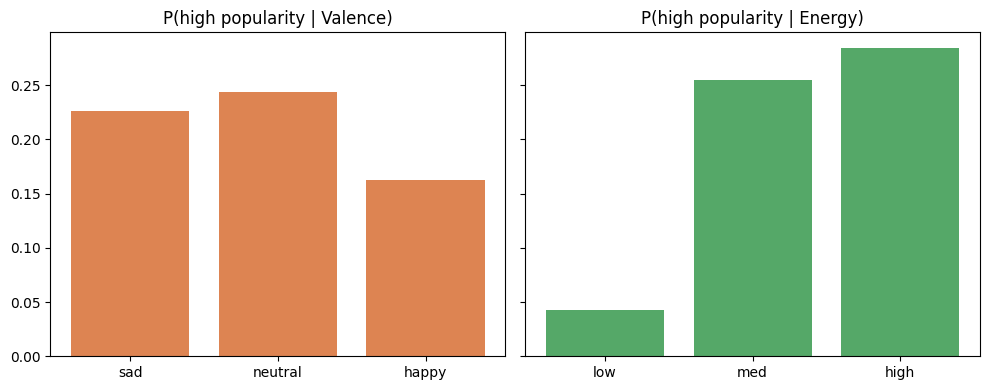

In [10]:
valence_results = {}
for v in ['sad', 'neutral', 'happy']:
    r = infer.query(variables=['Popularity'], evidence={'Valence': v}, show_progress=False)
    valence_results[v] = dict(zip(r.state_names['Popularity'], r.values))['high']

energy_results = {}
for e in ['low', 'med', 'high']:
    r = infer.query(variables=['Popularity'], evidence={'Energy': e}, show_progress=False)
    energy_results[e] = dict(zip(r.state_names['Popularity'], r.values))['high']

print("P(high popularity | Valence):", {k: round(v, 3) for k, v in valence_results.items()})
print("P(high popularity | Energy): ", {k: round(v, 3) for k, v in energy_results.items()})

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(valence_results.keys(), valence_results.values(), color='#DD8452')
axes[0].set_title('P(high popularity | Valence)')
axes[1].bar(energy_results.keys(), energy_results.values(), color='#55A868')
axes[1].set_title('P(high popularity | Energy)')
plt.tight_layout()
plt.savefig('query2_valence_energy.png', dpi=150)
plt.show()

**Observation:** Energy shows a strong, monotonic effect (4.3% -> 25.5% -> 28.4% as energy
goes low -> med -> high), while valence barely matters and is *not* monotonic
(22.6% / 24.4% / 16.2% for sad / neutral / happy). This suggests energy is a much stronger
driver of popularity than mood in this dataset — arguably the most interesting finding of
the analysis.

### Question 3: Best-case vs worst-case combined scenario

Finally, we combine multiple pieces of evidence to see the full spread the model can produce.

                                                   low    med   high
Best-case (pop/danceable/energetic/happy)        0.437  0.346  0.217
Worst-case (classical/low-dance/low-energy/sad)  0.888  0.087  0.025


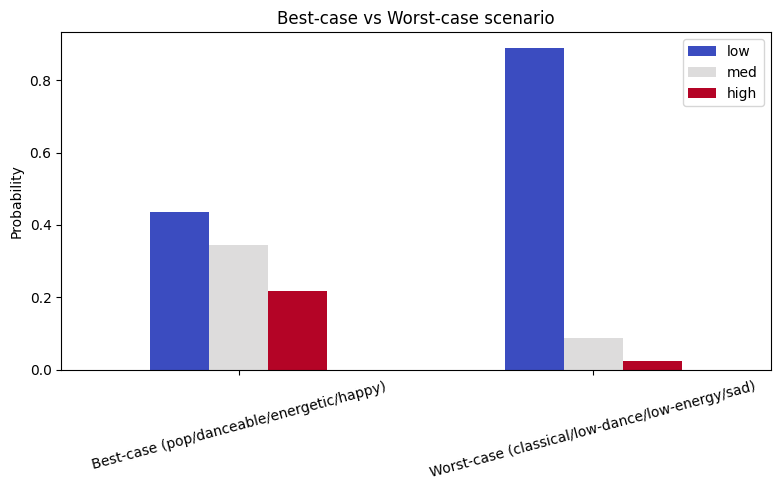

In [11]:
best_case = infer.query(variables=['Popularity'],
    evidence={'Genre': 'pop', 'Danceability': 'high', 'Energy': 'high',
              'Valence': 'happy', 'Explicit': False},
    show_progress=False)
worst_case = infer.query(variables=['Popularity'],
    evidence={'Genre': 'classical', 'Danceability': 'low', 'Energy': 'low',
              'Valence': 'sad', 'Explicit': False},
    show_progress=False)

best = dict(zip(best_case.state_names['Popularity'], best_case.values))
worst = dict(zip(worst_case.state_names['Popularity'], worst_case.values))

comp_df = pd.DataFrame({'Best-case (pop/danceable/energetic/happy)': best,
                        'Worst-case (classical/low-dance/low-energy/sad)': worst}).T[['low','med','high']]
print(comp_df.round(3))

comp_df.plot(kind='bar', figsize=(8, 5), colormap='coolwarm')
plt.title('Best-case vs Worst-case scenario')
plt.ylabel('Probability')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('query3_scenarios.png', dpi=150)
plt.show()

**Observation:** The combined scenarios show a large spread — best-case reaches 21.7%
P(high popularity) vs only 2.5% for the worst-case, with worst-case dominated by an 88.8%
chance of low popularity. This confirms the network captures a meaningful, non-trivial
relationship between style features and popularity, rather than collapsing to similar
predictions regardless of evidence.

## 7. Conclusion

Using a small, custom-defined Bayesian Network over six Spotify track features, we found that
**energy** is a much stronger driver of predicted popularity than **valence** (mood), and that
**genre** alone creates large shifts in popularity odds (classical/jazz underperform relative
to pop/hip-hop/metal/edm). Combining favorable evidence across all features produces a
sizeable swing in predicted popularity (2.5% to 21.7% chance of "high" popularity),
demonstrating that the network captures meaningful structure in the data.

**Limitations:** continuous features were discretized into only 3 bins each, which loses
some information; the network structure was defined manually based on domain intuition
rather than learned or validated statistically; and the dataset was restricted to 6 genres
for tractability, so results may not generalize to the full genre space.